In [1]:
%load_ext autoreload
%autoreload 2
import logging
import warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from ocularrigidity.data.measurements.cohort import Study, build_cohort
from ocularrigidity.stats.plot import regression_plot_with_stats
from ocularrigidity.stats.temporal import baseline_vs_slope_wide

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="The figure layout has changed to tight")
ROOT_CARDIAC = Path("/media/clement/HD/Santiago/OcularRigidity/FullPipeline/")

df = build_cohort(root=ROOT_CARDIAC, study=Study.PROSPECTIVE, overwrite=False)
n_eyes = df.groupby(["PatientId", "Eye"]).ngroups

MIN_VISITS = 3
MIN_SPAN_YEARS = 1

PROGRESSION = [
    ("MD", "MD slope (dB/year)"),
    ("PSD", "PSD slope (dB/year)"),
    ("G RNFL Thickness", "Global RNFL slope (\u03bcm/year)"),
    ("G BMO MRW", "Global BMO-MRW slope (\u03bcm/year)"),
]

K_LABEL = "Ocular Rigidity at first visit (mmHg/\u03bcL)"


def slope_table(x, y, min_points=MIN_VISITS, min_span=MIN_SPAN_YEARS):
    d = baseline_vs_slope_wide(df, x, y, min_points=min_points)
    return d[d["span_years"] >= min_span]


class DummyContextManager:
    def __enter__(self):
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        pass


cm = plt.xkcd
cm = DummyContextManager

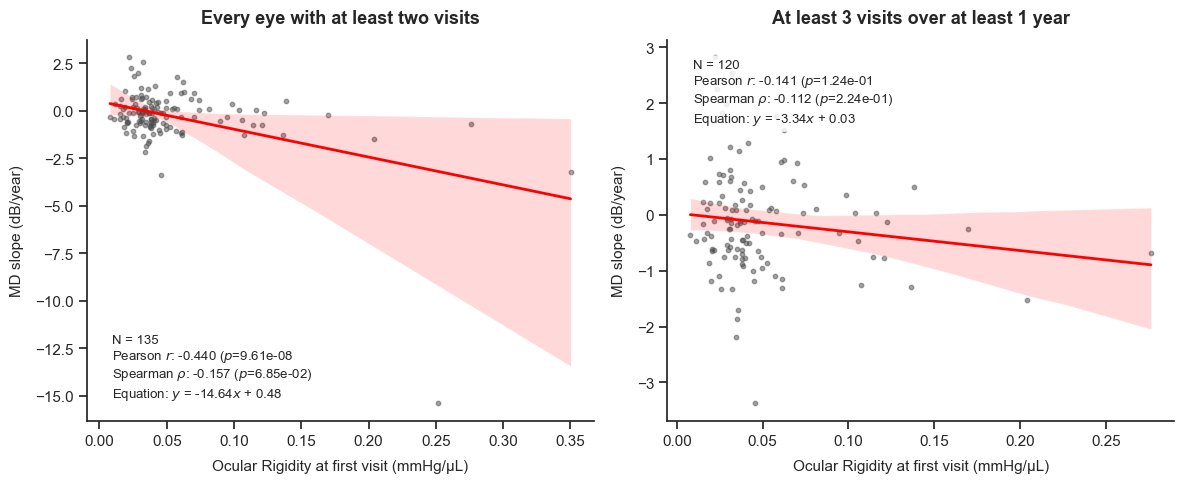

In [2]:
# | label: fig-slope-reliability
with cm():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    regression_plot_with_stats(
        df=baseline_vs_slope_wide(df, "K", "MD", min_points=2),
        x="K_baseline",
        y="MD_slope",
        xlabel=K_LABEL,
        ylabel="MD slope (dB/year)",
        title="Every eye with at least two visits",
        ax=axes[0],
        equal_axis=False,
        print_stats=False,
        legend_position="lower left",
    )
    regression_plot_with_stats(
        df=slope_table("K", "MD"),
        x="K_baseline",
        y="MD_slope",
        xlabel=K_LABEL,
        ylabel="MD slope (dB/year)",
        title="At least 3 visits over at least 1 year",
        ax=axes[1],
        equal_axis=False,
        print_stats=False,
    )
    plt.show()

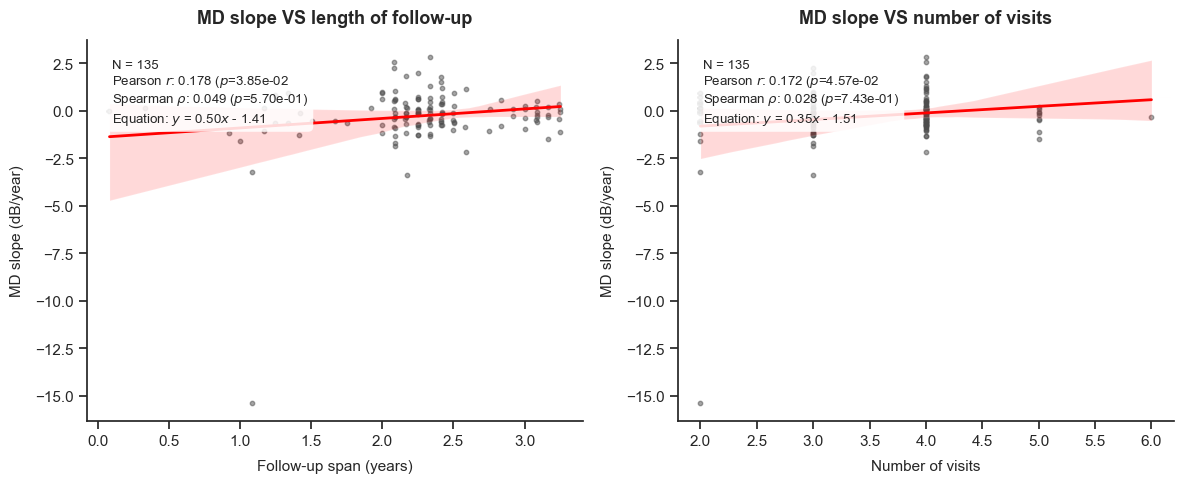

In [3]:
# | label: fig-slope-vs-followup
with cm():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    raw = baseline_vs_slope_wide(df, "K", "MD", min_points=2)
    regression_plot_with_stats(
        df=raw,
        x="span_years",
        y="MD_slope",
        xlabel="Follow-up span (years)",
        ylabel="MD slope (dB/year)",
        title="MD slope VS length of follow-up",
        ax=axes[0],
        equal_axis=False,
        print_stats=False,
    )
    regression_plot_with_stats(
        df=raw,
        x="n_visits",
        y="MD_slope",
        xlabel="Number of visits",
        ylabel="MD slope (dB/year)",
        title="MD slope VS number of visits",
        ax=axes[1],
        equal_axis=False,
        print_stats=False,
    )
    plt.show()

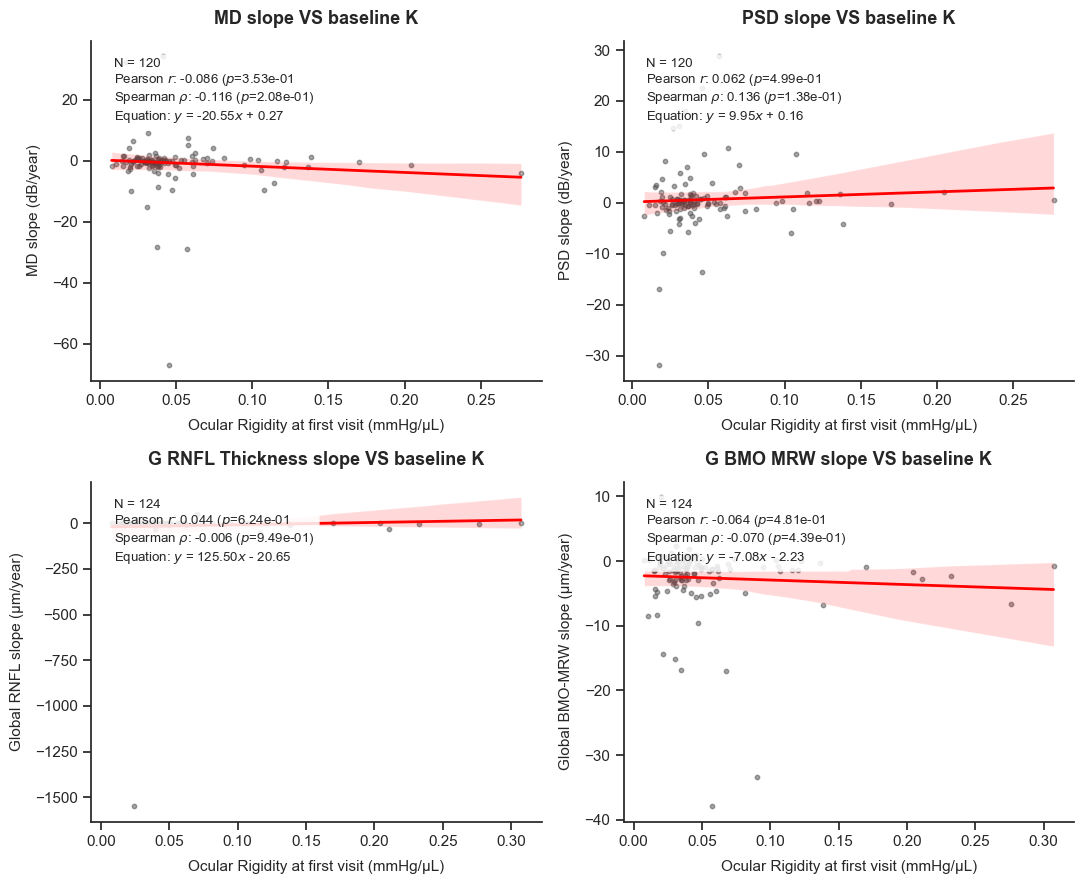

In [4]:
# | label: fig-K-vs-progression
with cm():
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
    for i, (col, ylabel) in enumerate(PROGRESSION):
        regression_plot_with_stats(
            df=slope_table("K", col),
            x="K_baseline",
            y=f"{col}_lsnr",
            xlabel=K_LABEL,
            ylabel=ylabel,
            title=f"{col} slope VS baseline K",
            ax=axes[i // 2, i % 2],
            equal_axis=False,
            print_stats=False,
        )
    plt.show()

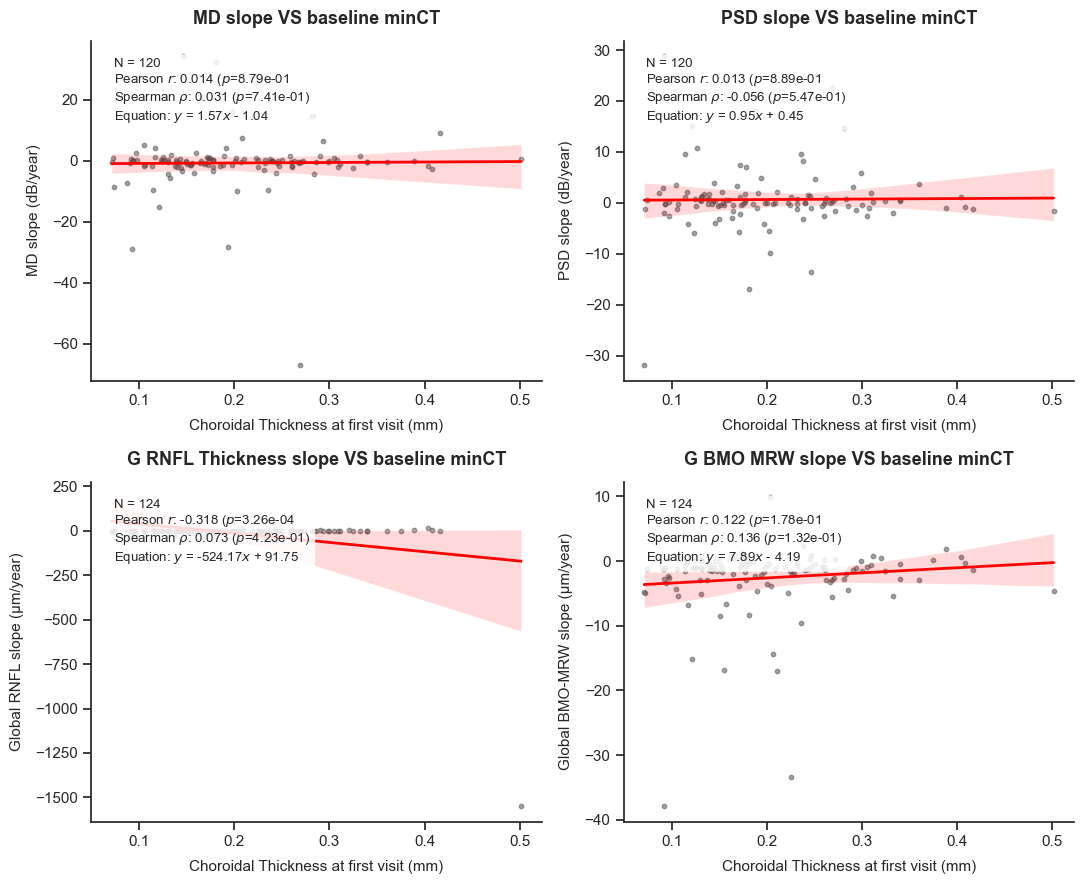

In [5]:
# | label: fig-CT-vs-progression
with cm():
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
    for i, (col, ylabel) in enumerate(PROGRESSION):
        regression_plot_with_stats(
            df=slope_table("minCT", col),
            x="minCT_baseline",
            y=f"{col}_lsnr",
            xlabel="Choroidal Thickness at first visit (mm)",
            ylabel=ylabel,
            title=f"{col} slope VS baseline minCT",
            ax=axes[i // 2, i % 2],
            equal_axis=False,
            print_stats=False,
        )
    plt.show()

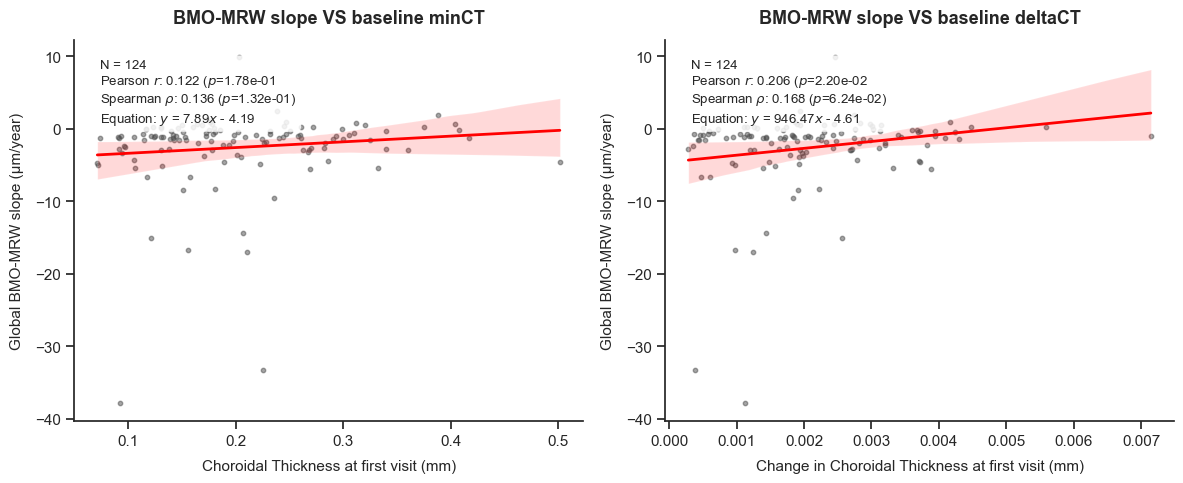

In [6]:
# | label: fig-CT-vs-MRW-slope
with cm():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    for ax, (col, xlabel) in zip(
        axes,
        [
            ("minCT", "Choroidal Thickness at first visit (mm)"),
            ("deltaCT", "Change in Choroidal Thickness at first visit (mm)"),
        ],
    ):
        regression_plot_with_stats(
            df=slope_table(col, "G BMO MRW"),
            x=f"{col}_baseline",
            y="G BMO MRW_lsnr",
            xlabel=xlabel,
            ylabel="Global BMO-MRW slope (\u03bcm/year)",
            title=f"BMO-MRW slope VS baseline {col}",
            ax=ax,
            equal_axis=False,
            print_stats=False,
        )
    plt.show()

In [7]:
import seaborn as sns
from scipy import stats

PREDICTORS = ["K", "minCT", "deltaCT", "OPA", "AxialLength", "Age", "IOP"]
IOP_LABEL = "Intraocular Pressure at first visit (mmHg)"
SHORT_NAMES = {
    "MD": "MD",
    "PSD": "PSD",
    "G RNFL Thickness": "Global RNFL",
    "G BMO MRW": "Global BMO-MRW",
}


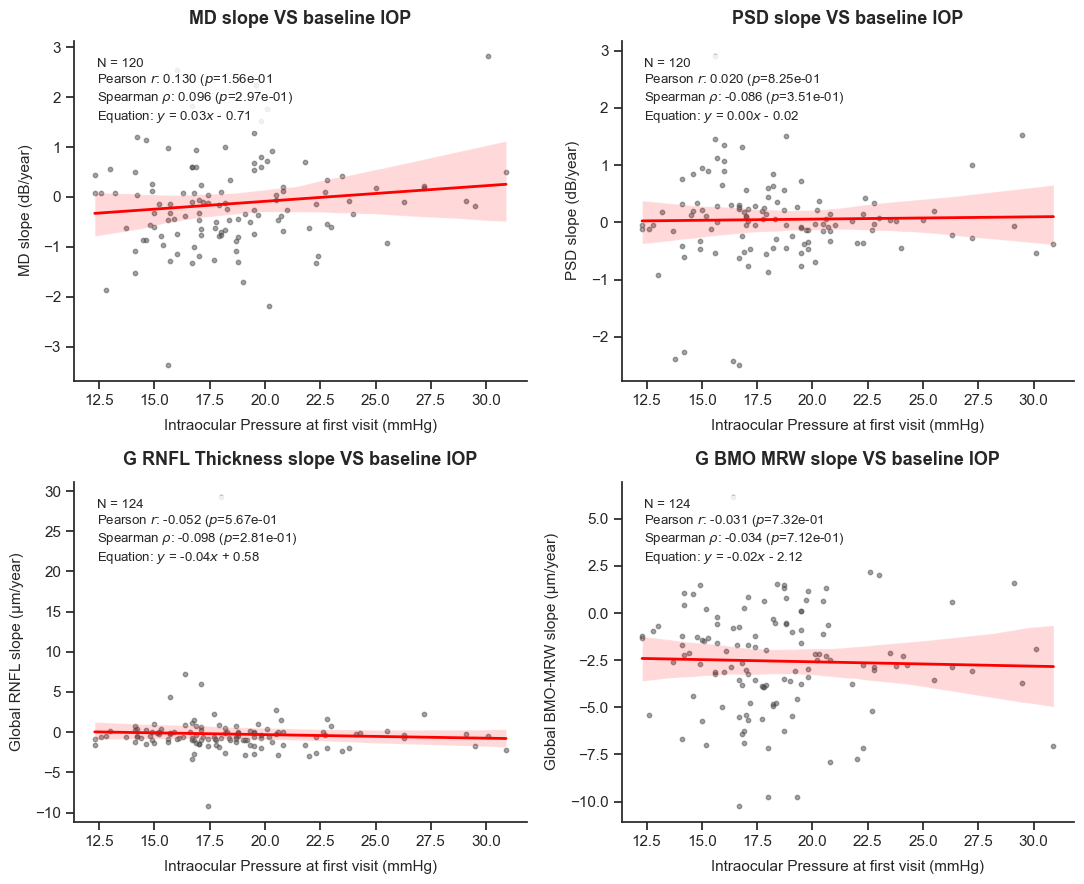

In [8]:
# | label: fig-IOP-vs-progression
with cm():
    fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
    for i, (col, ylabel) in enumerate(PROGRESSION):
        regression_plot_with_stats(
            df=slope_table("IOP", col),
            x="IOP_baseline",
            y=f"{col}_slope",
            xlabel=IOP_LABEL,
            ylabel=ylabel,
            title=f"{col} slope VS baseline IOP",
            ax=axes[i // 2, i % 2],
            equal_axis=False,
            print_stats=False,
        )
    plt.show()


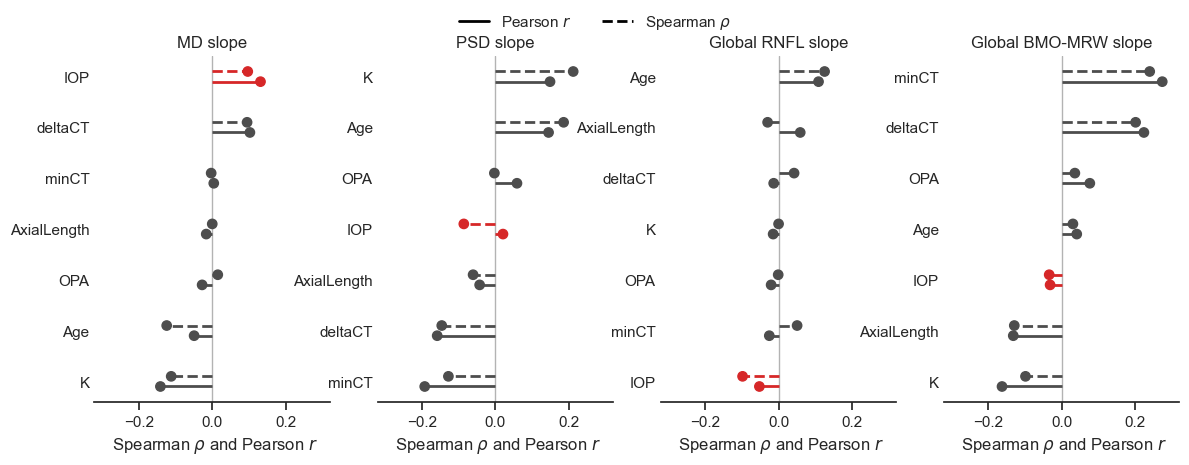

In [9]:
# | label: fig-predictor-comparison
with cm():
    fig, axes = plt.subplots(1, 4, figsize=(14, 4.5), sharex=True)
    for ax, (col, ylabel) in zip(axes, PROGRESSION):
        vals = []
        for p in PREDICTORS:
            d = slope_table(p, col)
            r, _ = stats.pearsonr(d[f"{p}_baseline"], d[f"{col}_slope"])
            rho = stats.spearmanr(d[f"{p}_baseline"], d[f"{col}_slope"]).correlation
            vals.append((p, r, rho))
        vals.sort(key=lambda t: t[1])
        names = [v[0] for v in vals]
        rs = [v[1] for v in vals]
        rhos = [v[2] for v in vals]
        colors = ["#d62728" if n == "IOP" else "#4d4d4d" for n in names]
        ax.axvline(0, color="0.7", linewidth=1, zorder=0)
        ax.hlines(
            np.arange(len(names)) - 0.1, 0, rs, color=colors, linewidth=2, zorder=1
        )
        ax.hlines(
            np.arange(len(names)) + 0.1,
            0,
            rhos,
            color=colors,
            linewidth=2,
            zorder=1,
            linestyle="dashed",
        )
        ax.scatter(rs, np.arange(len(names)) - 0.1, color=colors, s=45, zorder=2)
        ax.scatter(rhos, np.arange(len(names)) + 0.1, color=colors, s=45, zorder=2)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names)
        ax.set_title(f"{SHORT_NAMES[col]} slope")
        ax.set_xlabel(" Spearman $\\rho$ and Pearson $r$")
        ax.set_xlim(-0.32, 0.32)

        sns.despine(ax=ax, left=True)
        ax.tick_params(axis="y", length=0)
    # Set a global legend for the figure
    handles = [
        plt.Line2D([0], [0], color="black", lw=2, label="Pearson $r$"),
        plt.Line2D(
            [0], [0], color="black", lw=2, linestyle="dashed", label="Spearman $\\rho$"
        ),
    ]
    # Add some spacing between the subplots and the legend
    plt.subplots_adjust(hspace=1.0)
    fig.legend(handles=handles, loc="upper center", ncol=4, frameon=False)
    plt.show()


In [12]:
import yaml

spans = df.groupby(["PatientId", "Eye"])["YearMonth"].nunique()
raw_md = baseline_vs_slope_wide(df, "K", "MD", min_points=2)
kept = [len(slope_table("K", col)) for col, _ in PROGRESSION]
worst = raw_md.loc[raw_md["MD_slope"].idxmin()]

with open("../_variables.yml", "w") as f:
    yaml.safe_dump(
        {
            "pred": {
                "min_visits": MIN_VISITS,
                "min_span": MIN_SPAN_YEARS,
                "n_eyes": int(df.groupby(["PatientId", "Eye"]).ngroups),
                "visits_min": int(spans.min()),
                "visits_max": int(spans.max()),
                "median_followup": round(float(raw_md["span_years"].median()), 1),
                "n_kept_min": int(min(kept)),
                "n_kept_max": int(max(kept)),
                "worst_md_slope": int(round(worst["MD_slope"])),
                "worst_md_visits": int(worst["n_visits"]),
                "worst_md_span": round(float(worst["span_years"]), 1),
            }
        },
        f,
        sort_keys=False,
    )
